# Use of PSF simulations code

In [23]:
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from torch import nn
from tqdm import tqdm
from torch.optim import SGD, Adam, AdamW
import torch.nn.functional as F
import copy

if you feed scalars, all the computation is performed with numpy, otherwise it uses pyTorch. The goal is that when using torch, all the variables are stored as tensors in the good device (cpu or gpu). 

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using GPU


In [3]:
N_photons=5000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength in nm
f_tube=200 # tube lens focal in mm
MAG=200/150 # second magnification

N_photons=torch.tensor(N_photons, device=device)
N=torch.tensor(N, device=device)
l_pixel=torch.tensor(l_pixel, device=device)
NA=torch.tensor(NA, device=device)
mag=torch.tensor(mag, device=device)
lambd=torch.tensor(lambd, device=device)
f_tube=torch.tensor(f_tube, device=device)
MAG=torch.tensor(MAG, device=device)

In [4]:
NPSF = 100

In [5]:
N_photons=5000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength in nm
f_tube=200 # tube lens focal in mm
MAG=200/150 # second magnification

N_photons=torch.tensor(N_photons, device=device)
N=torch.tensor(N, device=device)
l_pixel=torch.tensor(l_pixel, device=device)
NA=torch.tensor(NA, device=device)
mag=torch.tensor(mag, device=device)
lambd=torch.tensor(lambd, device=device)
f_tube=torch.tensor(f_tube, device=device)
MAG=torch.tensor(MAG, device=device)

In [6]:
xp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
yp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
z = torch.tensor([2.5*0.8 for k in range(NPSF)], device=device)
d_ = torch.tensor([-2.5 for k in range(NPSF)], device=device)
rho = torch.tensor(180*np.random.rand(NPSF), device=device)
eta = torch.tensor(180*np.random.rand(NPSF), device=device)
delta = torch.tensor(180*np.random.rand(NPSF), device=device)
second_plane = torch.tensor([0.3, 0, -0.3], device=device)
polar_projections = torch.tensor([0, 0, 0], device=device)
zernike_coefs_x = torch.zeros((3,15), device=device)
zernike_coefs_y = torch.zeros((3,15), device=device)

In [7]:
x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, device=device)

In [8]:
phase_mask = torch.stack([torch.ones((N,N), device=device), torch.ones((N,N), device=device), torch.ones((N,N), device=device)])

# Basis function version

In [9]:
# u and v are meshgrids corresponding to the image plane coordinates
# M is the basis PSF matrix  --> see theoretical description

# THIS PART IS DEPENDANT ONTHE SPATIAL COORDINATES OF THE EMITTER AND THE FOCUS POSITION BUT NOT THE ORIENTATION

In [10]:
zernike_base = generate_zernike_base(r_cut=r_cut, N=N, zernike_order=4, device=device)

In [11]:
u, v, M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                    Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                    phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                    second_plane=second_plane, polar_projections=polar_projections, N=N,
                    l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG,
                   polar_offset=20., polar_offset2=20., device=device)

C:\Users\Amaury\anaconda3\envs\amaury_gpu\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [12]:
psf = noise(PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons), QE=1, EM=1, b=0., sigma_b=0., sigma_r=0., bias=0.)
psf.shape

torch.Size([100, 3, 2, 154, 154])

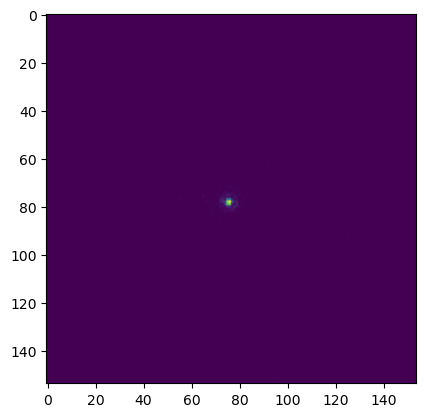

In [13]:
plt.imshow(psf[0,2,1].cpu().detach().numpy())

In [14]:
cent = psf.shape[3]//2

# building a network for the position

In [15]:
blockA = nn.Sequential(
          nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
          nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
        nn.MaxPool2d(2),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU()
        ) 

In [16]:
# ---------------------
# Inception-ResNet Block
# ---------------------
class InceptionResNetBlockA(nn.Module):
    def __init__(self):
        super().__init__()

        # Branch 1: 1x1 convolution
        self.branch1 = nn.Sequential(nn.Conv2d(128, 32, kernel_size=1),
        nn.BatchNorm2d(32),
    nn.ReLU())

        # Branch 2: 1x1 + 3x3 convolution
        self.branch2 = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=1),
            nn.BatchNorm2d(32),
    nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
    nn.ReLU()
        )

        # Branch 3: 
        self.branch3 = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=1),
            nn.BatchNorm2d(32),
    nn.ReLU(),
            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
    nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
    nn.ReLU()
        )

        # Combine branches
        self.conv_linear = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(64)

        self.shortcut = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1),
            nn.BatchNorm2d(64)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out = torch.cat([out1, out2, out3], dim=1)
        out = self.conv_linear(out)
        out = self.bn(out)
        out += residual  # Residual connection
        return F.relu(out)


In [17]:
resnetA = InceptionResNetBlockA()
backbone = nn.Sequential(blockA,
                      resnetA,
                      nn.MaxPool2d(2),
                      nn.Flatten(),
                      nn.Linear(1600, 256),
                      nn.BatchNorm1d(256),
    nn.ReLU(),
                      nn.Dropout(p=0.3),
                    nn.Linear(256, 256),
                         nn.BatchNorm1d(256),
                      nn.ReLU(),
                      nn.Linear(256, 64),
                      nn.BatchNorm1d(64),
    nn.ReLU(),
                     )

In [18]:
def mse(a,b):
    return torch.mean((a-b)**2)

# train a backbone for 2D

backbone.load_state_dict(torch.load("backbone.pth"))  # 2️⃣ load weights
backbone.eval()  # 3️⃣ set to eval mode (disable dropout, etc.)

In [19]:
model2d = nn.Sequential(backbone,
                      nn.Linear(64, 2),
                       nn.BatchNorm1d(2),
                      nn.Tanh())

In [24]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
optimizer = AdamW(model2d.parameters(), lr=1e-4)
num_params = sum(p.numel() for p in model2d.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 1082566


In [25]:
loss_record = []
def train(model, n_batch):
    model.to(device)
    model.train()
    for batch in tqdm(range(n_batch)):
        xp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        yp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        z = torch.tensor(2.5*0.8+(np.random.rand(NPSF)-0.5)*1.5, device=device)
        rho = torch.tensor(180*np.random.rand(NPSF), device=device)
        eta = torch.tensor(180*np.random.rand(NPSF), device=device)
        delta = torch.tensor(180*np.random.rand(NPSF), device=device)
        u, v, M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                        Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                        phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                        l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG,
                       polar_offset=20., polar_offset2=20., device=device)
        psf = (noise(PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons), QE=1, EM=1, b=0., sigma_b=0.001, sigma_r=0., bias=0.001).to(dtype=torch.float32)[:,:,:,cent-10:cent+10,cent-10:cent+10]).reshape((NPSF,6,20,20))
        pred = model(psf)
        loss = mse(pred[:,:2], torch.stack([xp/0.2, yp/0.2]).permute(1, 0))
        #loss = mse(pred[:,:3], torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75]).permute(1, 0))
        #loss = mse(pred, torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75, (rho-90)/90, (delta-90)/90]).permute(1, 0))
        if (batch*10)%n_batch==0:
            print(loss, pred[0])
            plt.rcParams['figure.figsize'] = [25, 5]
            fig, ax = plt.subplots(1,5)
            ax[0].scatter(xp.cpu().detach().numpy(), (0.2*pred[:,0]).cpu().detach().numpy())
            ax[0].plot(xp.cpu().detach().numpy(), xp.cpu().detach().numpy(), c='r')
            #ax[1].scatter(z.cpu().detach().numpy(), 2.5*0.8+(0.75*pred[:,2]).cpu().detach().numpy())
            #ax[1].plot(z.cpu().detach().numpy(), z.cpu().detach().numpy(), c='r')
           # ax[2].scatter(rho.cpu().detach().numpy(),  90+(90*pred[:,3]).cpu().detach().numpy())
            #ax[2].plot(rho.cpu().detach().numpy(), rho.cpu().detach().numpy(), c='r')
            #ax[3].scatter(eta.cpu().detach().numpy(),  90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[3].plot(eta.cpu().detach().numpy(), eta.cpu().detach().numpy(), c='r')
            #ax[4].scatter(delta.cpu().detach().numpy(), 90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[4].plot(delta.cpu().detach().numpy(), delta.cpu().detach().numpy(), c='r')
            plt.show()
            del(fig, ax)
        loss_record.append(loss.detach().cpu())
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

  0%|          | 0/100 [00:00<?, ?it/s]

tensor(0.7187, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([-0.3387,  0.1904], device='cuda:0', grad_fn=<SelectBackward0>)


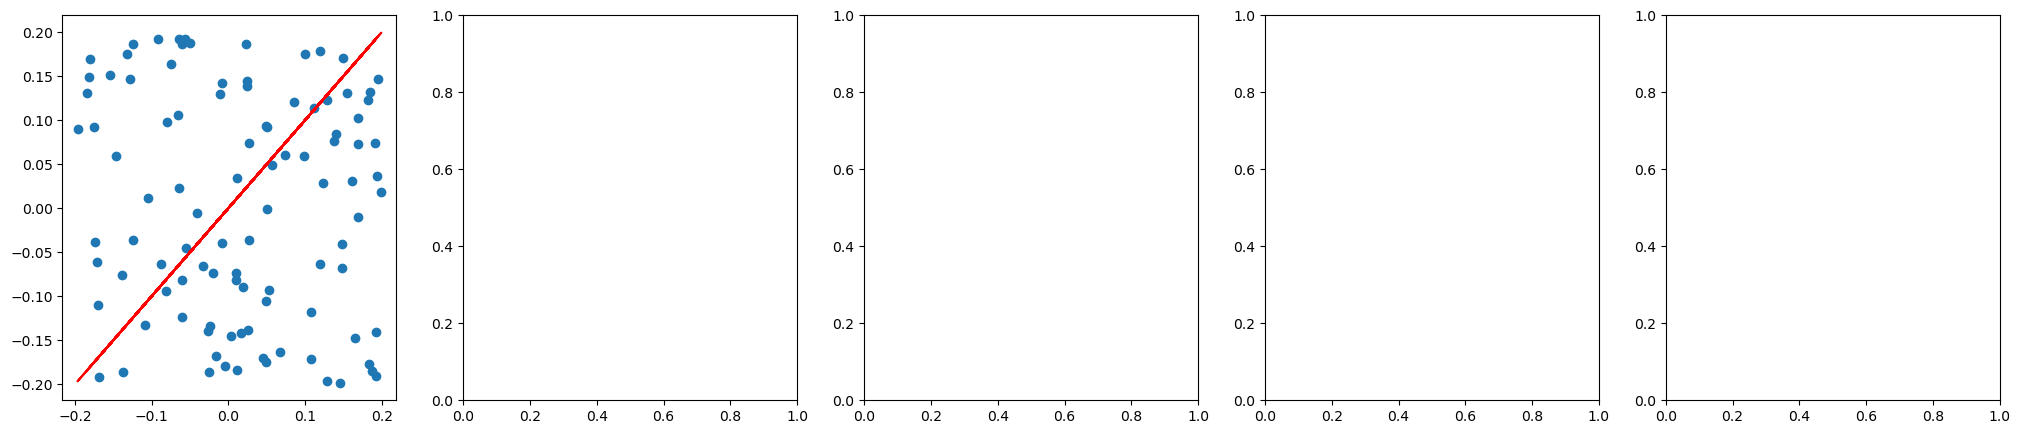

 10%|█         | 10/100 [00:12<01:44,  1.16s/it]

tensor(0.1413, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([ 0.1001, -0.1911], device='cuda:0', grad_fn=<SelectBackward0>)


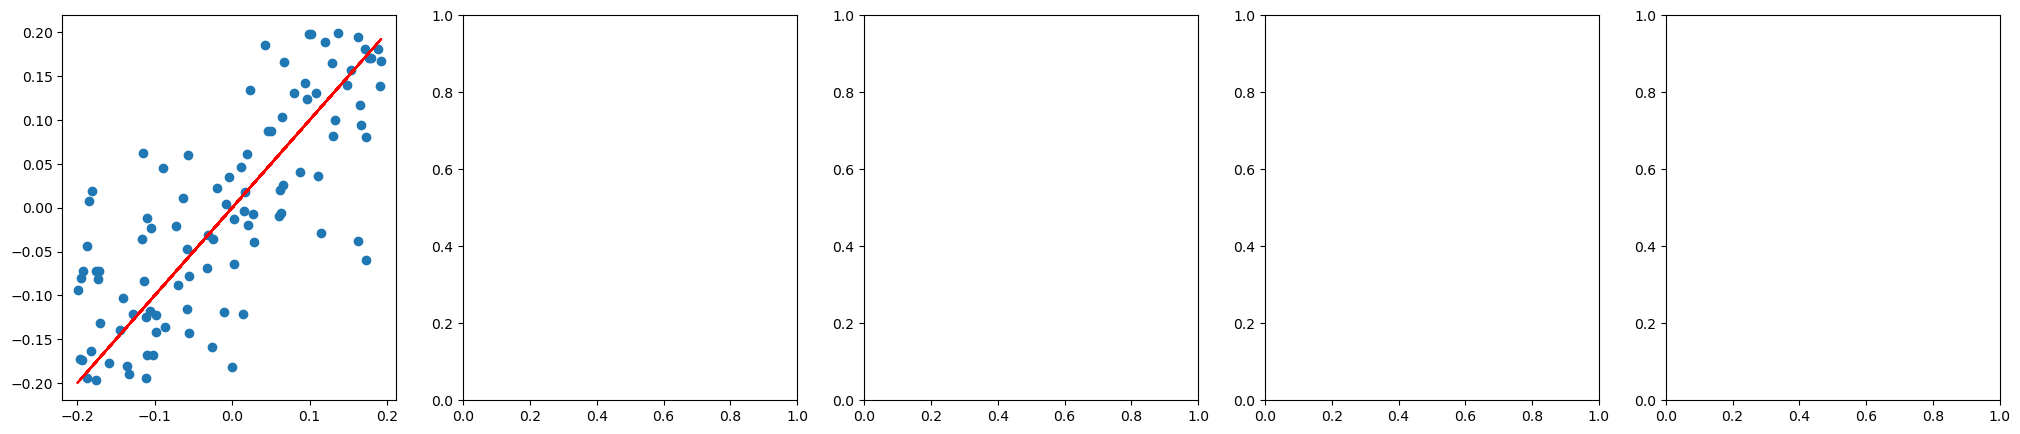

 20%|██        | 20/100 [00:23<01:29,  1.12s/it]

tensor(0.0871, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([-0.5601,  0.3766], device='cuda:0', grad_fn=<SelectBackward0>)


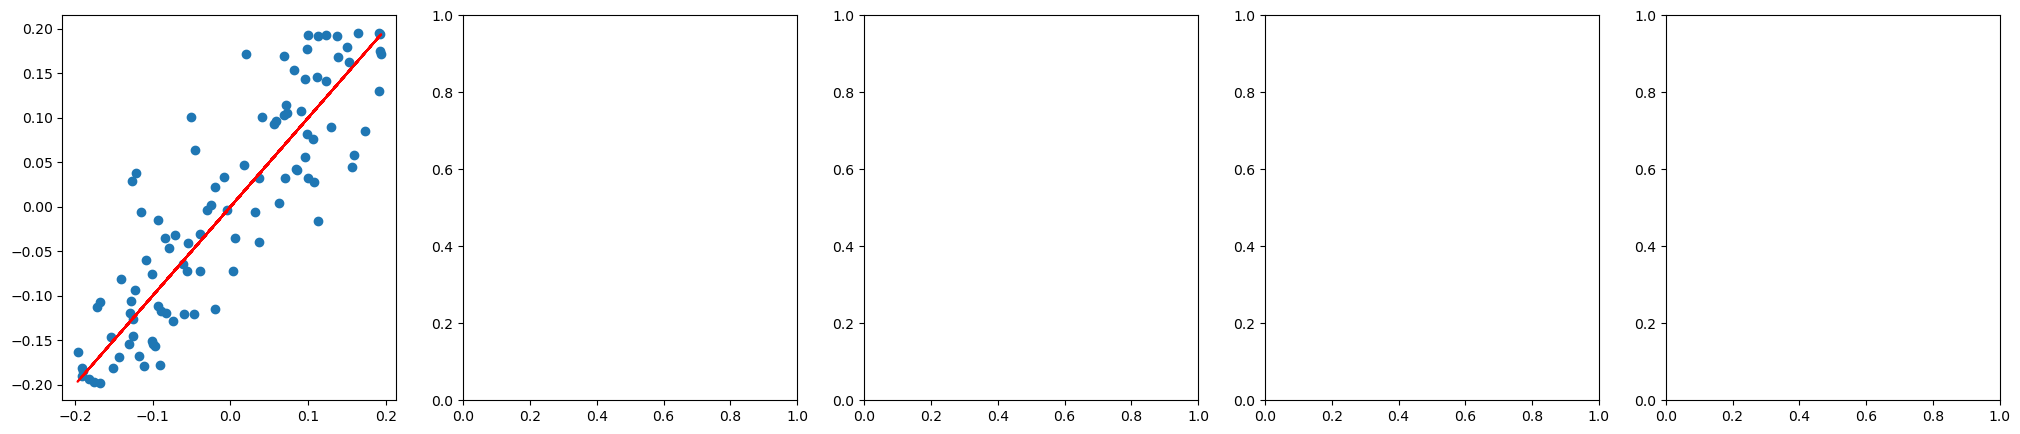

 30%|███       | 30/100 [00:35<01:19,  1.13s/it]

tensor(0.0841, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([0.1149, 0.3725], device='cuda:0', grad_fn=<SelectBackward0>)


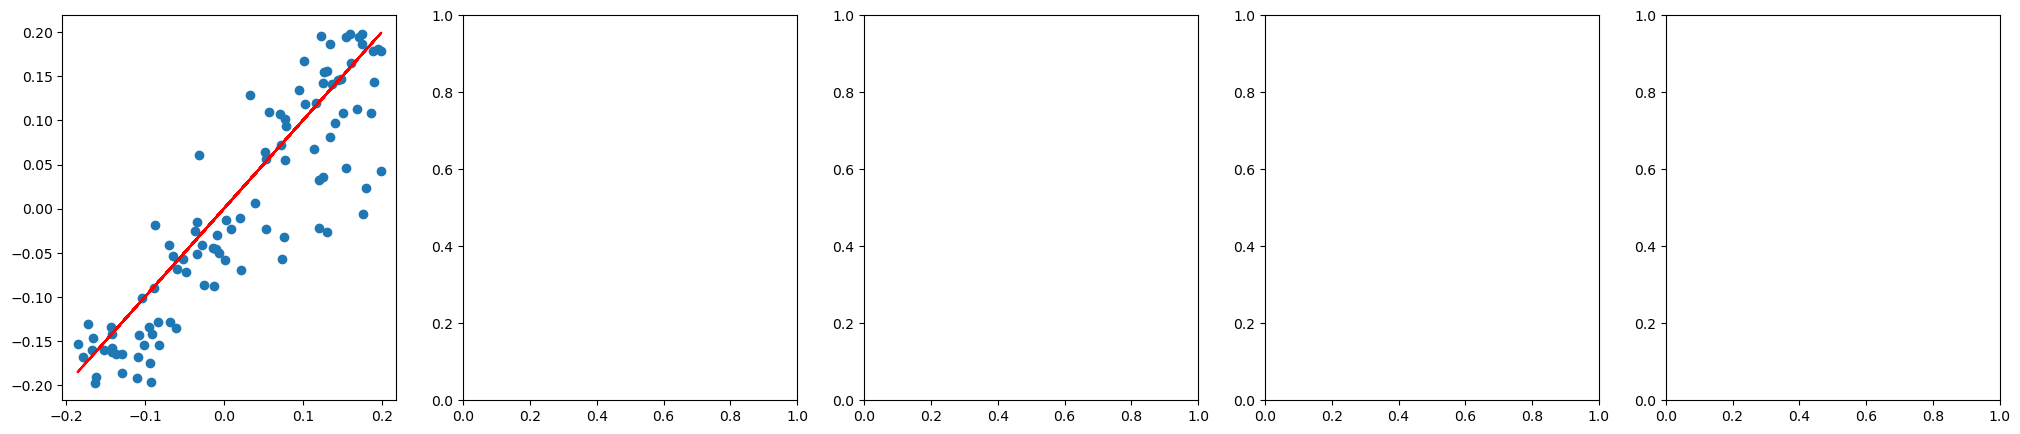

 40%|████      | 40/100 [00:47<01:08,  1.15s/it]

tensor(0.0844, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([-0.7364, -0.5124], device='cuda:0', grad_fn=<SelectBackward0>)


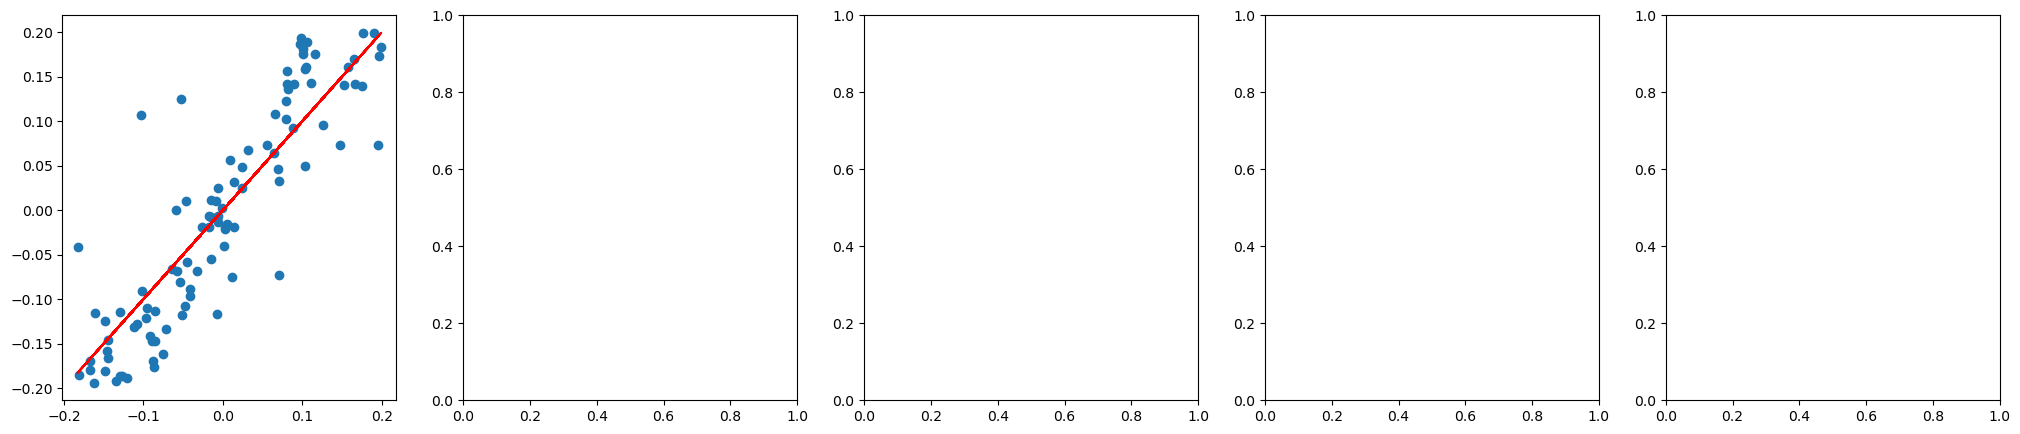

 50%|█████     | 50/100 [00:58<00:56,  1.13s/it]

tensor(0.0711, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([0.1536, 0.6995], device='cuda:0', grad_fn=<SelectBackward0>)


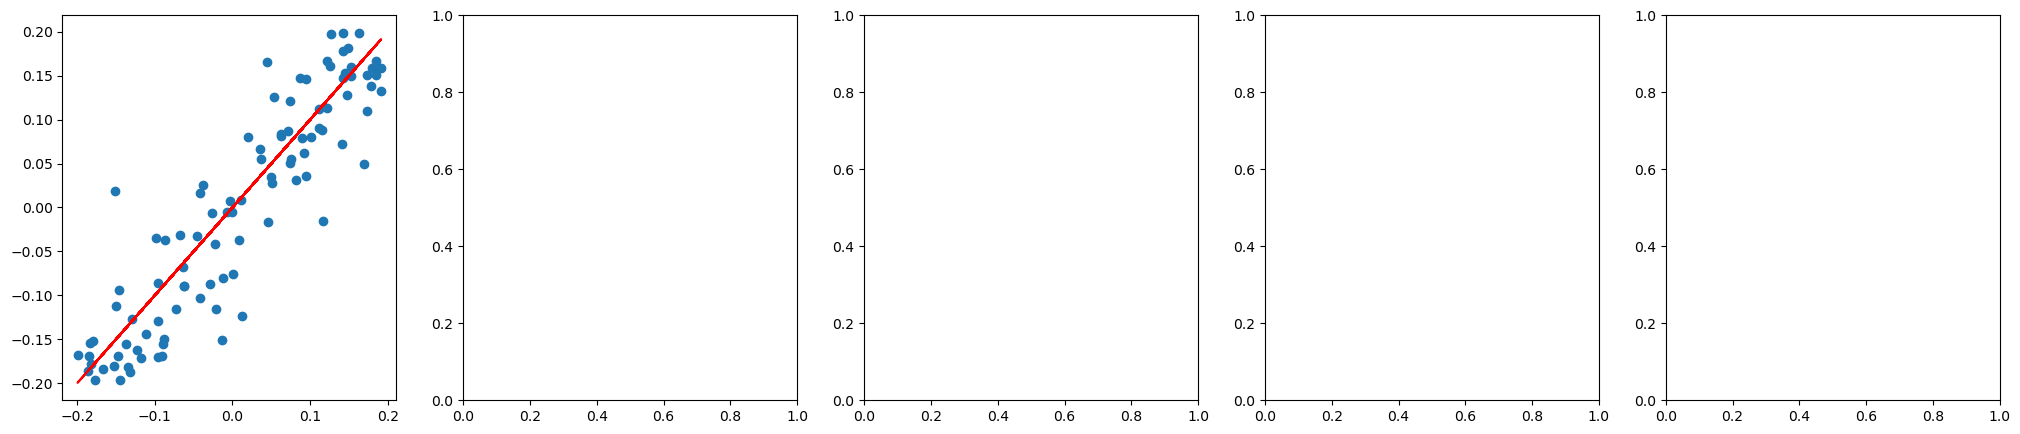

 60%|██████    | 60/100 [01:10<00:45,  1.14s/it]

tensor(0.0542, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([0.9397, 0.9748], device='cuda:0', grad_fn=<SelectBackward0>)


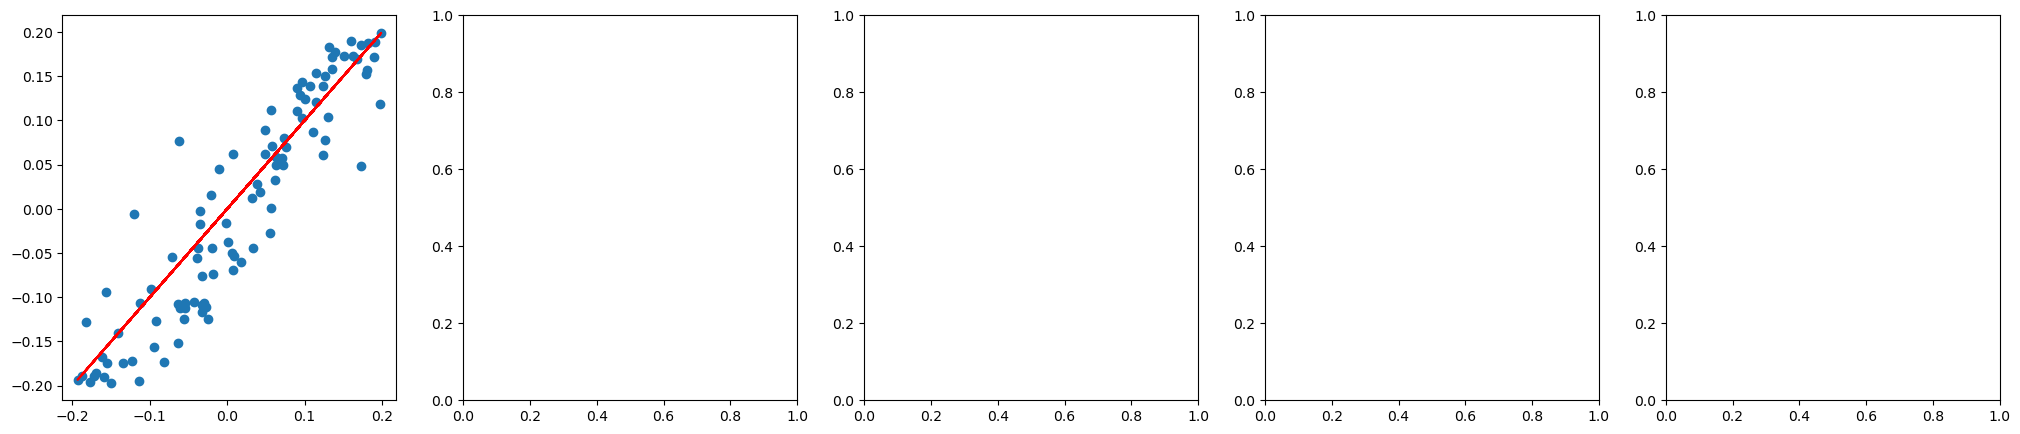

 70%|███████   | 70/100 [01:22<00:34,  1.14s/it]

tensor(0.0699, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([ 0.7681, -0.6985], device='cuda:0', grad_fn=<SelectBackward0>)


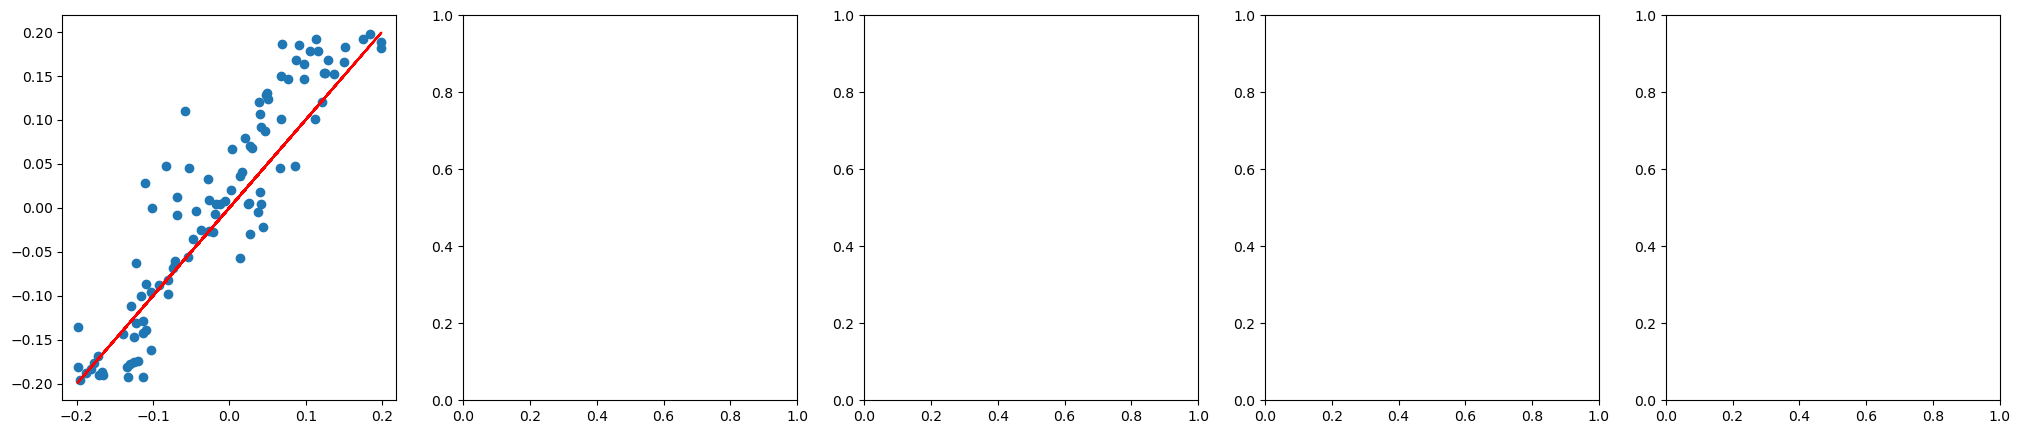

 80%|████████  | 80/100 [01:34<00:23,  1.15s/it]

tensor(0.0497, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([0.1775, 0.0755], device='cuda:0', grad_fn=<SelectBackward0>)


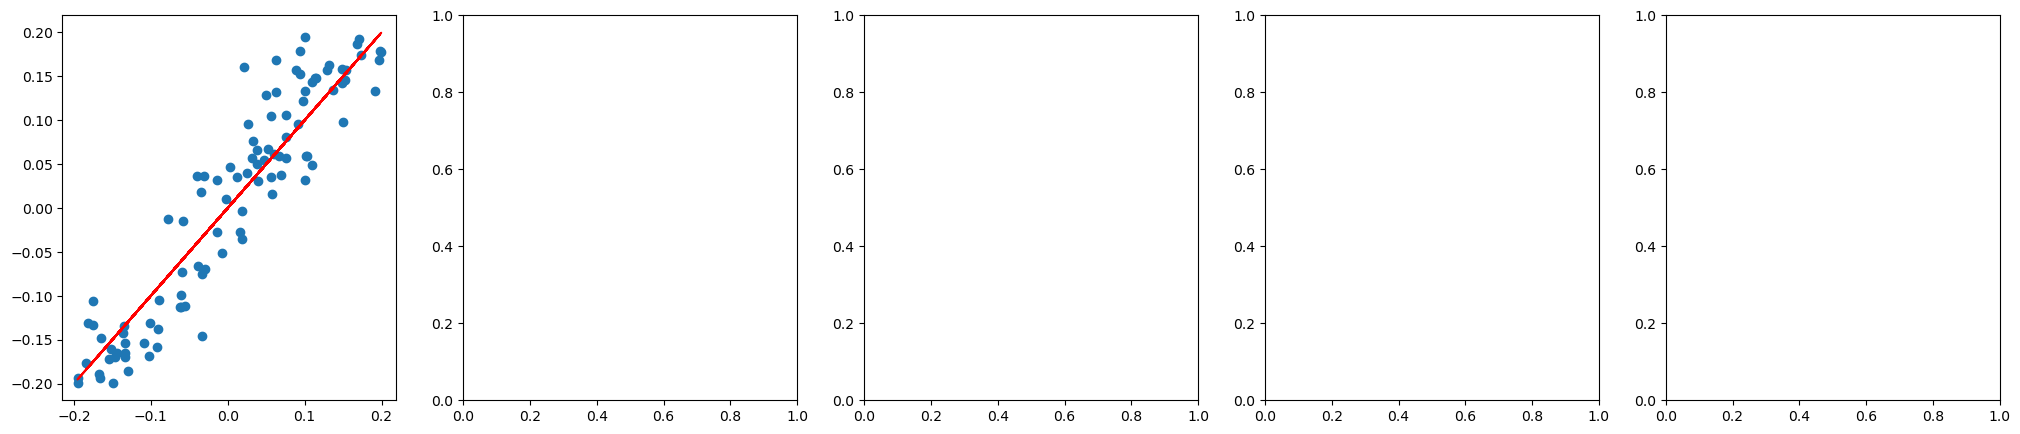

 90%|█████████ | 90/100 [01:46<00:11,  1.14s/it]

tensor(0.0381, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>) tensor([ 0.9637, -0.5580], device='cuda:0', grad_fn=<SelectBackward0>)


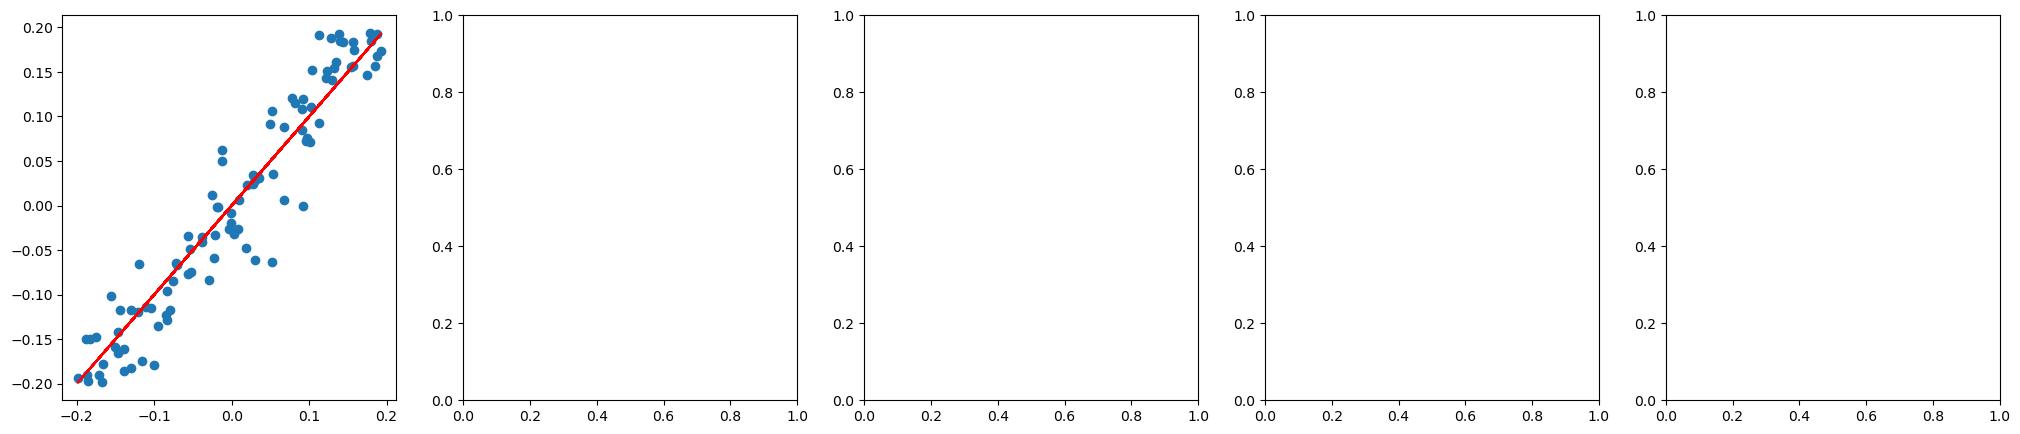

100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


In [26]:
train(model2d,100)

model2d.load_state_dict(torch.load("model2d.pth"))  # 2️⃣ load weights
model2d.eval()  # 3️⃣ set to eval mode (disable dropout, etc.)

In [27]:
backbone2 = copy.deepcopy(backbone)

backbone2.load_state_dict(torch.load("backbone2.pth"))  # 2️⃣ load weights
backbone2.eval()  # 3️⃣ set to eval mode (disable dropout, etc.)

# go to 3D

In [28]:
model3d = nn.Sequential(backbone2,
                      nn.Linear(64, 3),
                       nn.BatchNorm1d(3),
                      nn.Tanh())

model3d.load_state_dict(torch.load("model3d.pth"))  # 2️⃣ load weights
model3d.eval()  # 3️⃣ set to eval mode (disable dropout, etc.)

In [29]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
optimizer = AdamW(model3d.parameters(), lr=1e-4)
num_params = sum(p.numel() for p in model3d.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 1082633


In [30]:
NOISE GIT PULL

SyntaxError: invalid syntax (2502528464.py, line 1)

In [ ]:
loss_record = []
def train(model, n_batch):
    model.to(device)
    model.train()
    for batch in tqdm(range(n_batch)):
        xp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        yp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        z = torch.tensor(2.5*0.8+(np.random.rand(NPSF)-0.5)*1.5, device=device)
        rho = torch.tensor(180*np.random.rand(NPSF), device=device)
        eta = torch.tensor(180*np.random.rand(NPSF), device=device)
        delta = torch.tensor(180*np.random.rand(NPSF), device=device)
        u, v, M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                        Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                        phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                        l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG,
                       polar_offset=20., polar_offset2=20., device=device)
        psf = (noise(PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons), QE=1, EM=1, b=0., sigma_b=0.001, sigma_r=0., bias=0.001).to(dtype=torch.float32)[:,:,:,cent-10:cent+10,cent-10:cent+10]).reshape((NPSF,6,20,20))
        pred = model(psf)
        #loss = mse(pred[:,:2], torch.stack([xp/0.2, yp/0.2]).permute(1, 0))
        loss = mse(pred[:,:3], torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75]).permute(1, 0))
        #loss = mse(pred, torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75, (rho-90)/90, (delta-90)/90]).permute(1, 0))
        if (batch*10)%n_batch==0:
            print(loss, pred[0])
            plt.rcParams['figure.figsize'] = [25, 5]
            fig, ax = plt.subplots(1,5)
            ax[0].scatter(xp.cpu().detach().numpy(), (0.2*pred[:,0]).cpu().detach().numpy())
            ax[0].plot(xp.cpu().detach().numpy(), xp.cpu().detach().numpy(), c='r')
            ax[1].scatter(z.cpu().detach().numpy(), 2.5*0.8+(0.75*pred[:,2]).cpu().detach().numpy())
            ax[1].plot(z.cpu().detach().numpy(), z.cpu().detach().numpy(), c='r')
           # ax[2].scatter(rho.cpu().detach().numpy(),  90+(90*pred[:,3]).cpu().detach().numpy())
            #ax[2].plot(rho.cpu().detach().numpy(), rho.cpu().detach().numpy(), c='r')
            #ax[3].scatter(eta.cpu().detach().numpy(),  90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[3].plot(eta.cpu().detach().numpy(), eta.cpu().detach().numpy(), c='r')
            #ax[4].scatter(delta.cpu().detach().numpy(), 90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[4].plot(delta.cpu().detach().numpy(), delta.cpu().detach().numpy(), c='r')
            plt.show()
            del(fig, ax)
        loss_record.append(loss.detach().cpu())
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

In [ ]:
train(model3d,100)

In [ ]:
plt.plot(loss_record)

# Then orientation: begin by a fully connected for just rho and delta (ratiometric)

In [ ]:
backbone3 = copy.deepcopy(backbone2)

backbone3.load_state_dict(torch.load("backbone3.pth"))  # 2️⃣ load weights
backbone3.eval()  # 3️⃣ set to eval mode (disable dropout, etc.)

In [ ]:
rho_backbone = nn.AvgPool2d(17)
            nn.BatchNorm2d(4),
            nn.ReLU(),  
            nn.MaxPool2d(4)
            nn.BatchNorm2d(1),
            nn.ReLU(),   
            nn.Flatten(),
            nn.Linear(6,16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

In [ ]:
rho_end = nn.Sequential(
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8,2),
            nn.BatchNorm1d(2),
            nn.Tanh(),
        )

In [ ]:
rho_alone = nn.Sequential(rho_backbone, rho_end)

In [ ]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
optimizer = AdamW(rho_alone.parameters(), lr=1e-4)
num_params = sum(p.numel() for p in rho_alone.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

In [ ]:
loss_record = []
def train(model, n_batch):
    model.to(device)
    model.train()
    for batch in tqdm(range(n_batch)):
        xp = torch.tensor([0 for i in range(NPSF)], device=device)
        yp = torch.tensor([0 for i in range(NPSF)], device=device)
        z = torch.tensor([2.5*0.8 for i in range(NPSF)], device=device)
        rho = torch.tensor(180*np.random.rand(NPSF), device=device)
        eta = torch.tensor(180*np.random.rand(NPSF), device=device)
        delta = torch.tensor(180*np.random.rand(NPSF), device=device)
        u, v, M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                        Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                        phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                        l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG,
                       polar_offset=20., polar_offset2=20., device=device)
        psf = (noise(PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons), QE=1, EM=1, b=0., sigma_b=0.001, sigma_r=0., bias=0.001).to(dtype=torch.float32)[:,:,:,cent-10:cent+10,cent-10:cent+10]).reshape((NPSF,6,20,20))
        pred = model(psf)
        loss = mse(pred[:,:2], torch.stack([rho/90-90, delta/90-90]).permute(1, 0))
        #loss = mse(pred, torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75, (rho-90)/90, (delta-90)/90]).permute(1, 0))
        if (batch*10)%n_batch==0:
            print(loss, pred[0])
            plt.rcParams['figure.figsize'] = [25, 5]
            fig, ax = plt.subplots(1,5)
            #ax[0].scatter(xp.cpu().detach().numpy(), (0.2*pred[:,0]).cpu().detach().numpy())
            #ax[0].plot(xp.cpu().detach().numpy(), xp.cpu().detach().numpy(), c='r')
            #ax[1].scatter(z.cpu().detach().numpy(), 2.5*0.8+(0.75*pred[:,2]).cpu().detach().numpy())
            #ax[1].plot(z.cpu().detach().numpy(), z.cpu().detach().numpy(), c='r')
            ax[2].scatter(rho.cpu().detach().numpy(),  90+(90*pred[:,3]).cpu().detach().numpy())
            ax[2].plot(rho.cpu().detach().numpy(), rho.cpu().detach().numpy(), c='r')
            #ax[3].scatter(eta.cpu().detach().numpy(),  90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[3].plot(eta.cpu().detach().numpy(), eta.cpu().detach().numpy(), c='r')
            ax[4].scatter(delta.cpu().detach().numpy(), 90+(90*pred[:,4]).cpu().detach().numpy())
            ax[4].plot(delta.cpu().detach().numpy(), delta.cpu().detach().numpy(), c='r')
            plt.show()
            del(fig, ax)
        loss_record.append(loss.detach().cpu())
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

In [ ]:
train(rho_alone, 200)

# Then plug it into the 3D position

In [121]:
class model5D(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch1 = backbone3
        self.branch2 = rho_part
        # Combine branches
        self.combine =  nn.Sequential(nn.Linear(128, 64),
                        nn.BatchNorm1d(64),
                        nn.ReLU(),
                        nn.Linear(64, 32),
                        nn.BatchNorm1d(32),
                        nn.ReLU(),   
                        nn.Linear(32, 5),
                        nn.BatchNorm1d(5),
                        nn.Tanh())

    def forward(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out = torch.cat([out1, out2], dim=1)
        return self.combine(out)

In [122]:
model5d = model5D()

In [127]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
optimizer = Adam(model5d.parameters(), lr=1e-3)
num_params = sum(p.numel() for p in model5d.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 1158623


In [128]:
def mse2(a,b):
    return torch.mean((a[:,:3]-b[:,:3])**2)+torch.mean(((torch.abs(a[:,3]-b[:,3]))%0.5)**2)+torch.mean(((a[:,4:]-b[:,4:]))**2)

In [129]:
loss_record = []
def train2(model, n_batch):
    model.to(device)
    model.train()
    for batch in tqdm(range(n_batch)):
        xp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        yp = torch.tensor(0.2*(np.random.rand(NPSF)-0.5)*2, device=device)
        z = torch.tensor(2.5*0.8+(np.random.rand(NPSF)-0.5)*1.5, device=device)
        rho = torch.tensor(180*np.random.rand(NPSF), device=device)
        eta = torch.tensor(180*np.random.rand(NPSF), device=device)
        delta = torch.tensor(180*np.random.rand(NPSF), device=device)
        u, v, M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                        Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                        phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                        l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG,
                       polar_offset=20., polar_offset2=20., device=device)
        psf = (noise(PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons), QE=1, EM=1, b=0., sigma_b=0.001, sigma_r=0., bias=0.001).to(dtype=torch.float32)[:,:,:,cent-10:cent+10,cent-10:cent+10]).reshape((NPSF,6,20,20))
        pred = model(psf)
        loss = mse2(pred[:,:5], torch.stack([xp/0.2, yp/0.2, (z - 2.5*0.8)/0.75, (rho-90)/90, (delta-90)/90]).permute(1, 0))
        if (batch*10)%n_batch==0:
            print(loss, pred[0])
            plt.rcParams['figure.figsize'] = [25, 5]
            fig, ax = plt.subplots(1,5)
            ax[0].scatter(xp.cpu().detach().numpy(), (0.2*pred[:,0]).cpu().detach().numpy())
            ax[0].plot(xp.cpu().detach().numpy(), xp.cpu().detach().numpy(), c='r')
            ax[1].scatter(z.cpu().detach().numpy(), 2.5*0.8+(0.75*pred[:,2]).cpu().detach().numpy())
            ax[1].plot(z.cpu().detach().numpy(), z.cpu().detach().numpy(), c='r')
            ax[2].scatter(rho.cpu().detach().numpy(),  90+(90*pred[:,3]).cpu().detach().numpy())
            ax[2].plot(rho.cpu().detach().numpy(), rho.cpu().detach().numpy(), c='r')
            #ax[3].scatter(eta.cpu().detach().numpy(),  90+(90*pred[:,4]).cpu().detach().numpy())
            #ax[3].plot(eta.cpu().detach().numpy(), eta.cpu().detach().numpy(), c='r')
            ax[4].scatter(delta.cpu().detach().numpy(), 90+(90*pred[:,4]).cpu().detach().numpy())
            ax[4].plot(delta.cpu().detach().numpy(), delta.cpu().detach().numpy(), c='r')
            plt.show()
            del(fig, ax)
        loss_record.append(loss.detach().cpu())
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor(0.2256, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.2523,  0.6184, -0.5357, -0.8399, -0.4999], device='cuda:0',
       grad_fn=<SelectBackward0>)


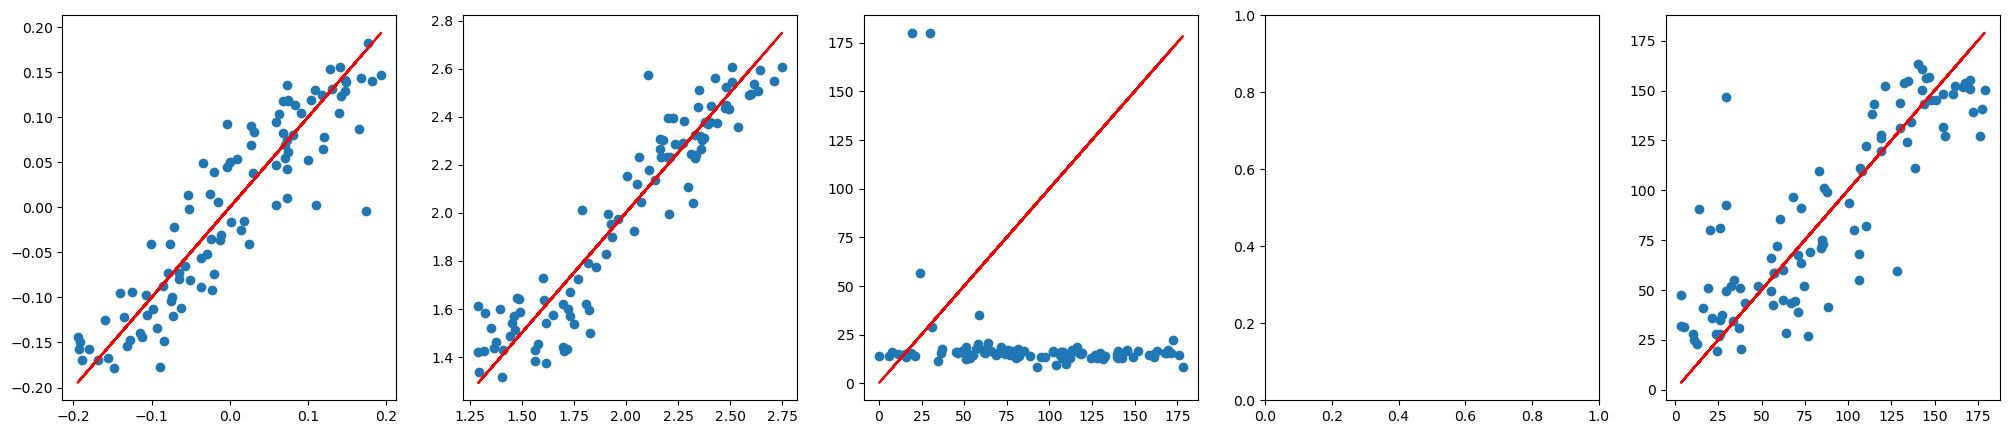

 10%|█         | 100/1000 [01:19<11:56,  1.26it/s]

tensor(0.1859, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([-0.5643,  0.1031,  0.8072, -0.8601, -0.5118], device='cuda:0',
       grad_fn=<SelectBackward0>)


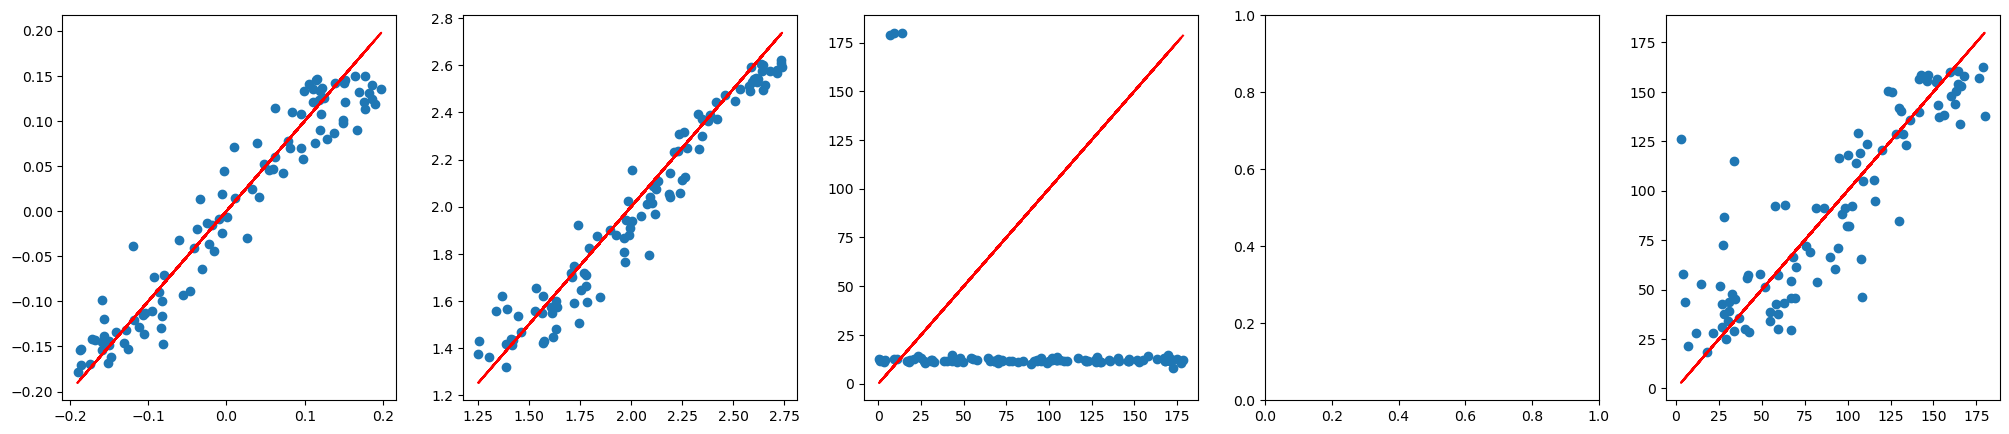

 20%|██        | 200/1000 [02:38<10:32,  1.26it/s]

tensor(0.1547, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.7089,  0.5131, -0.5020, -0.9184, -0.2534], device='cuda:0',
       grad_fn=<SelectBackward0>)


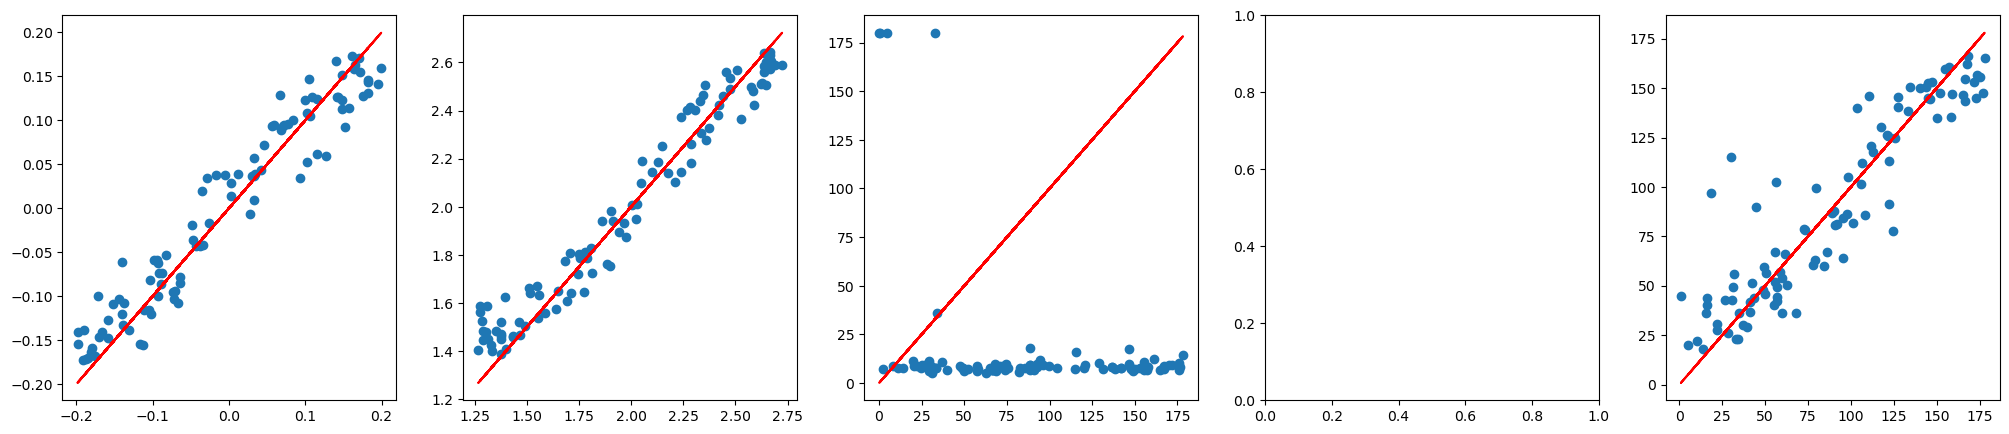

 30%|███       | 300/1000 [03:57<09:10,  1.27it/s]

tensor(0.1452, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([-0.3157, -0.0684,  0.0343, -0.8798, -0.6541], device='cuda:0',
       grad_fn=<SelectBackward0>)


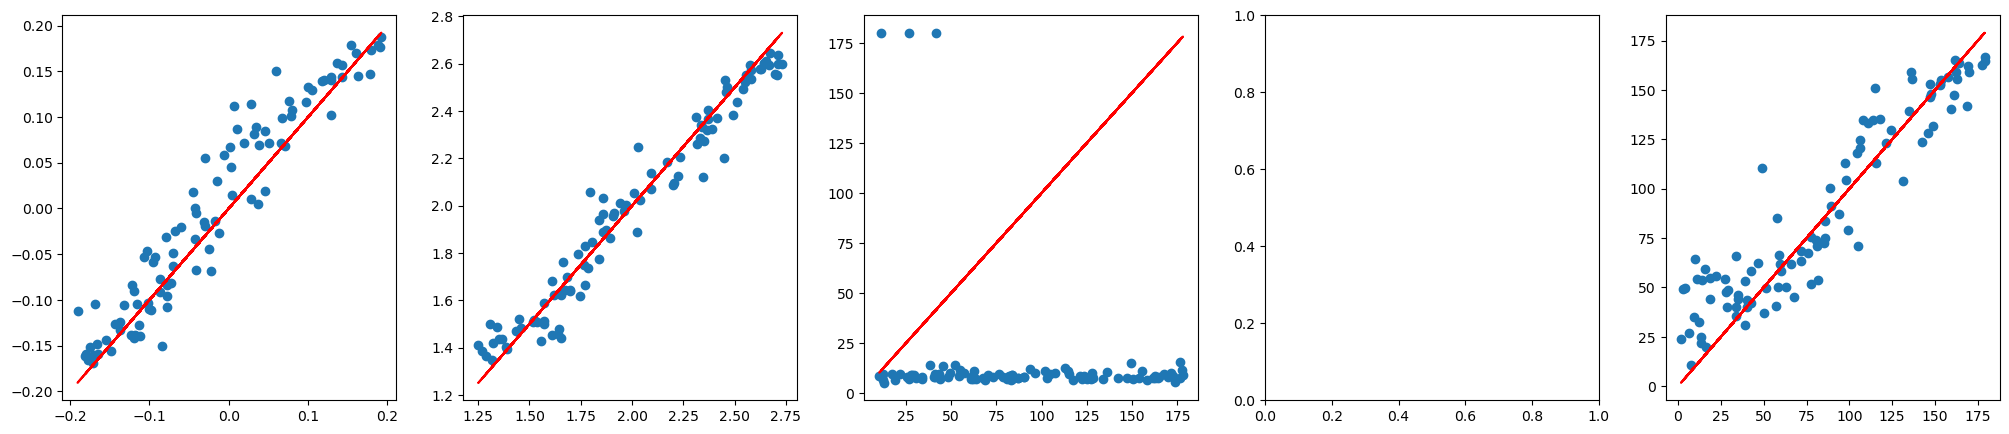

 40%|████      | 400/1000 [05:16<07:55,  1.26it/s]

tensor(0.1505, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.1501, -0.3854, -0.2106, -0.9204, -0.6736], device='cuda:0',
       grad_fn=<SelectBackward0>)


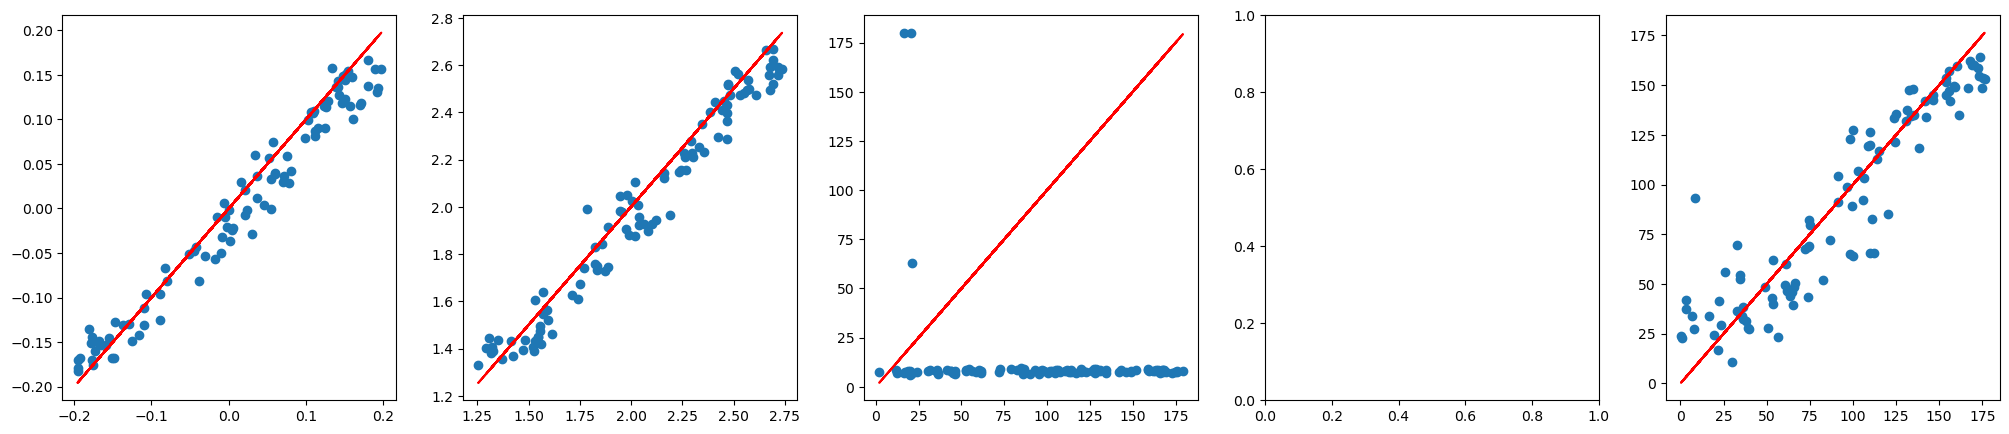

 50%|█████     | 500/1000 [06:35<06:33,  1.27it/s]

tensor(0.1589, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.7297,  0.7888, -0.1971, -0.9404, -0.7901], device='cuda:0',
       grad_fn=<SelectBackward0>)


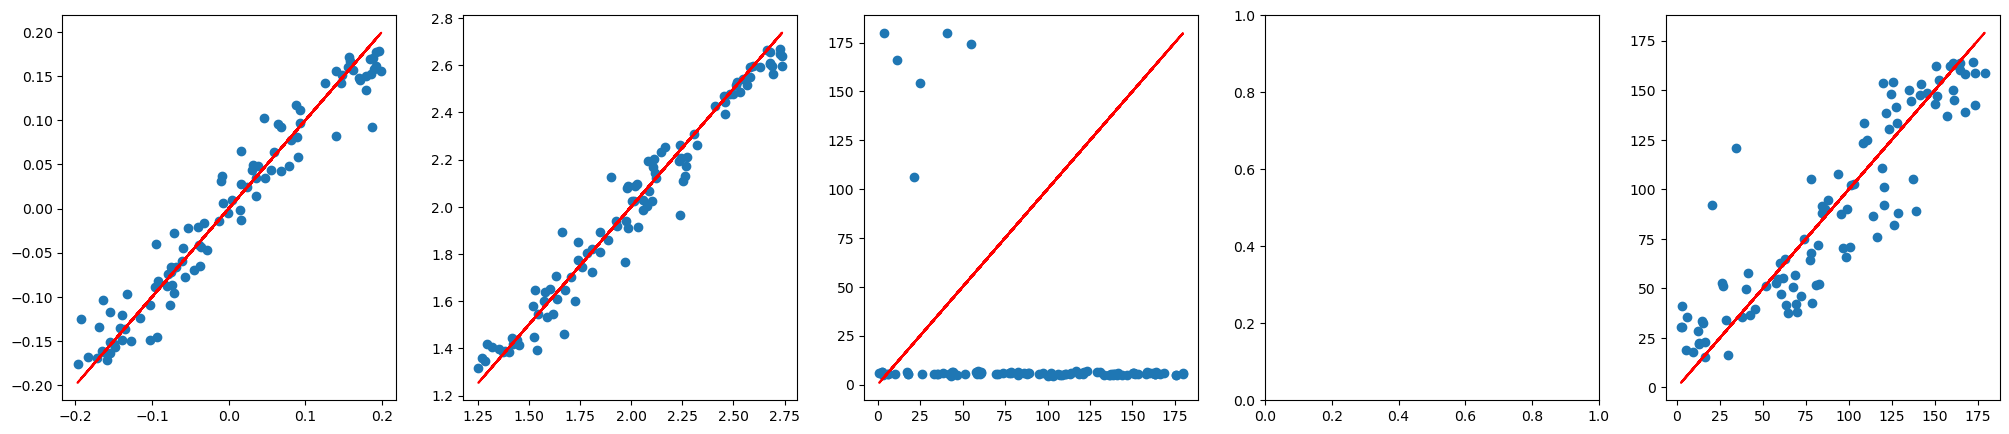

 60%|██████    | 600/1000 [07:54<05:14,  1.27it/s]

tensor(0.1464, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.3994, -0.3880,  0.2193,  1.0000, -0.6954], device='cuda:0',
       grad_fn=<SelectBackward0>)


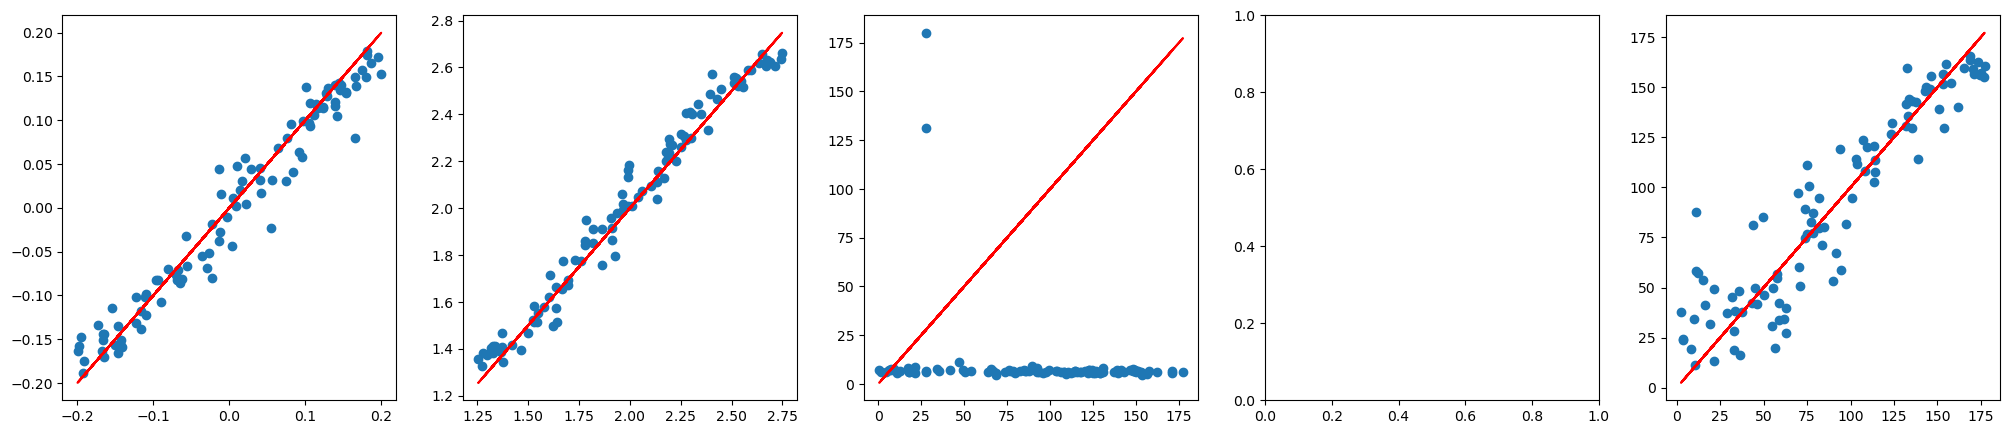

 70%|███████   | 700/1000 [09:13<03:57,  1.26it/s]

tensor(0.1481, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.5770, -0.1138,  0.8863, -0.9386,  0.6885], device='cuda:0',
       grad_fn=<SelectBackward0>)


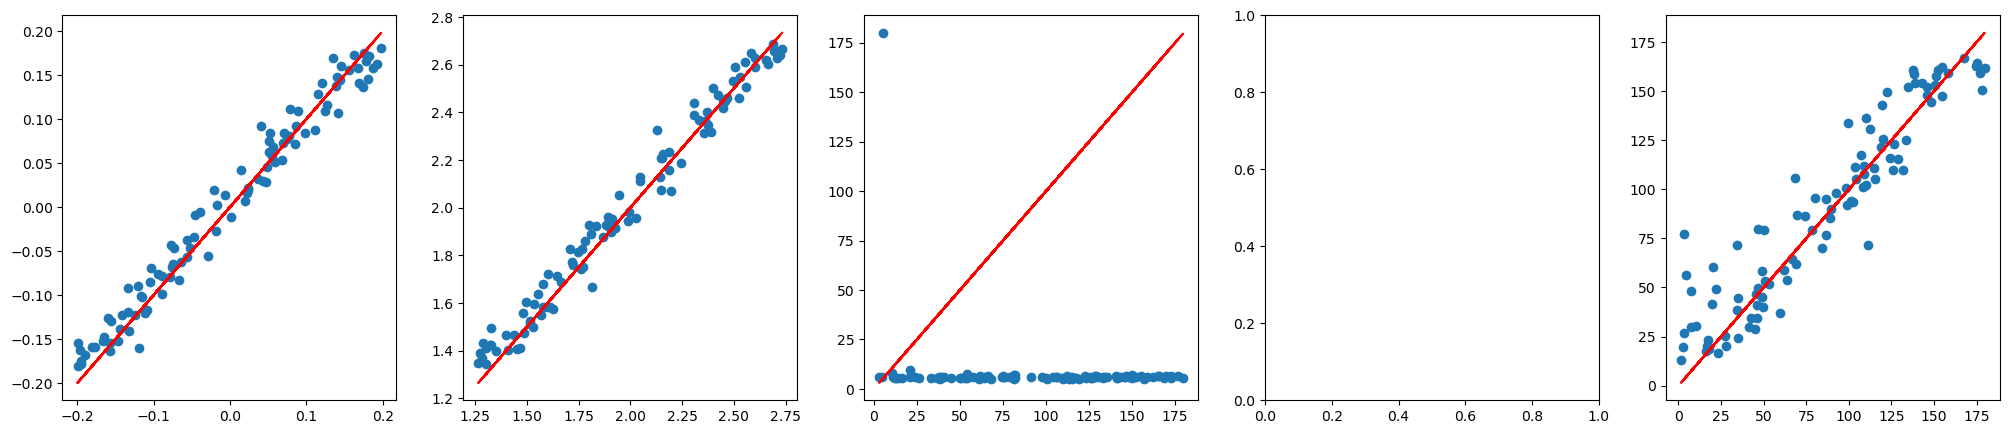

 80%|████████  | 800/1000 [10:32<02:38,  1.26it/s]

tensor(0.1227, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([-0.7404, -0.6073,  0.4189, -0.9336, -0.0457], device='cuda:0',
       grad_fn=<SelectBackward0>)


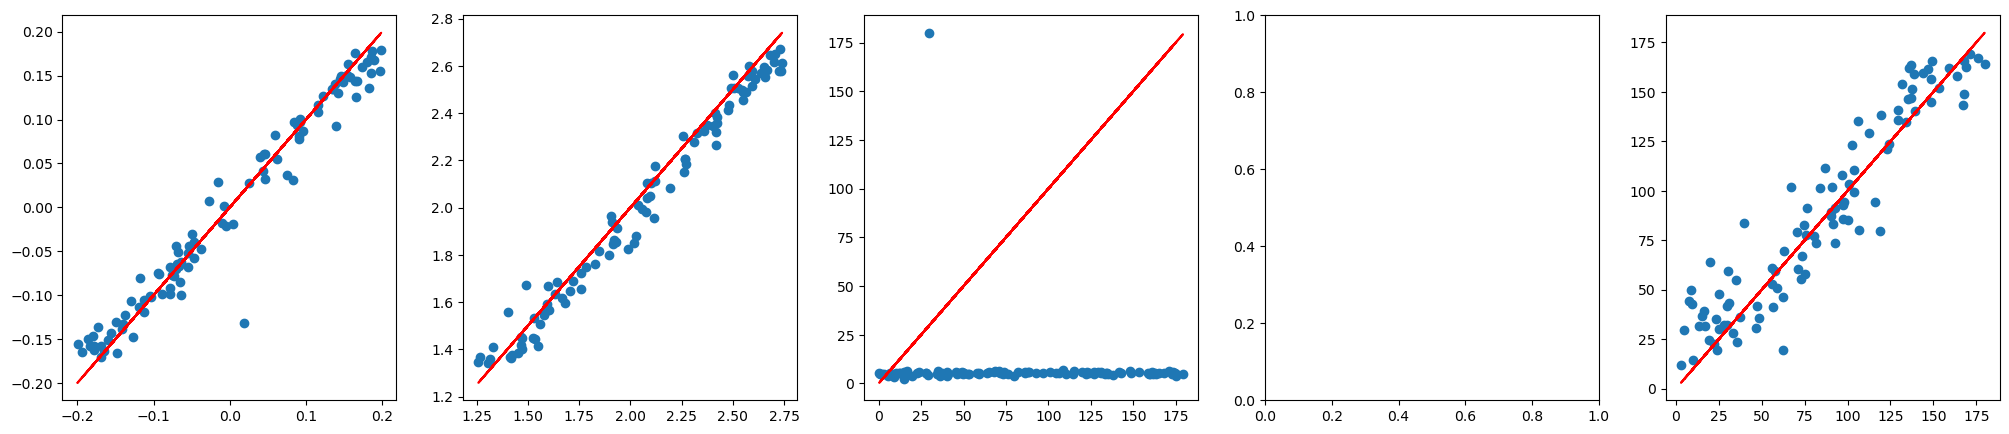

 90%|█████████ | 900/1000 [11:51<01:18,  1.27it/s]

tensor(0.1506, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>) tensor([ 0.8540,  0.1606, -0.8049, -0.9641,  0.7643], device='cuda:0',
       grad_fn=<SelectBackward0>)


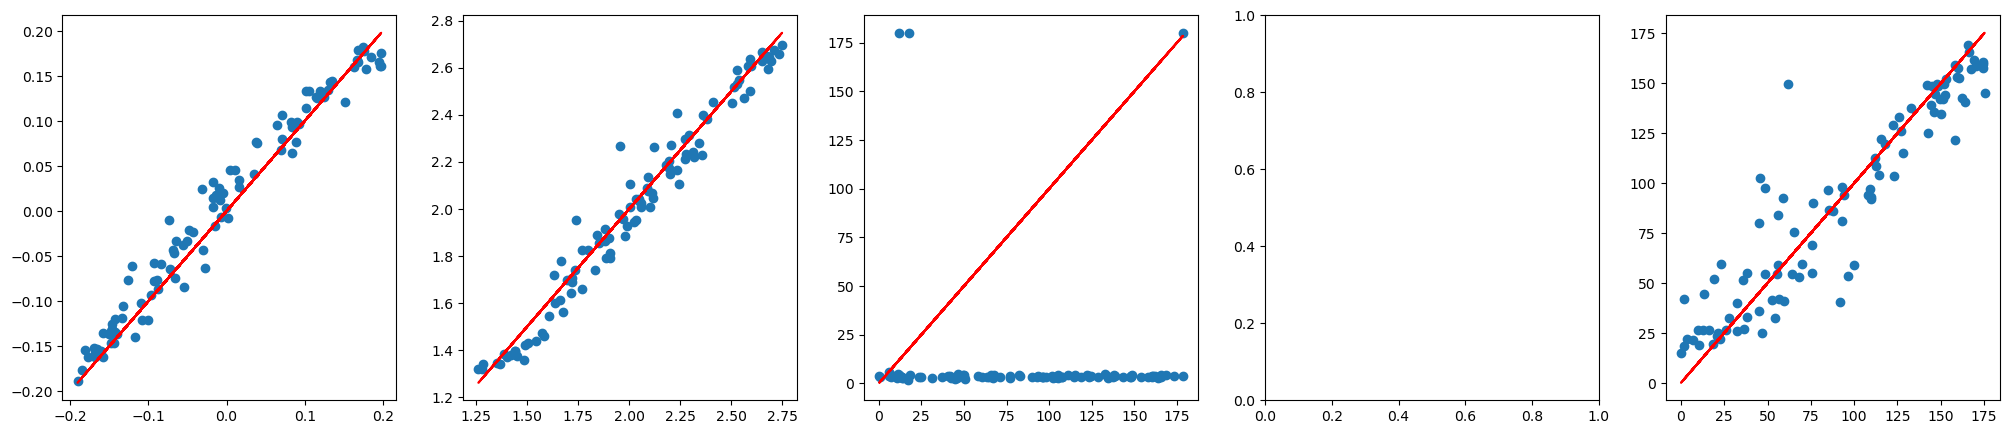

100%|██████████| 1000/1000 [13:09<00:00,  1.27it/s]


In [131]:
train2(model5d, 1000)

# then full 6D

In [132]:
torch.save(model2d.state_dict(), "model2d.pth")
torch.save(backbone.state_dict(), "backbone.pth")
torch.save(model3d.state_dict(), "model3d.pth")
torch.save(backbone2.state_dict(), "backbone2.pth")
torch.save(backbone3.state_dict(), "backbone3.pth")
torch.save(model5d.state_dict(), "model5d.pth")